In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver, InMemorySaver # for saving the states after each run
import time

c:\ML-DL\AgenticAI-LangGraph\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

from langchain_openrouter import ChatOpenRouter

llm = ChatOpenRouter(
    model="google/gemma-4-26b-a4b-it:free",
    temperature=0
)

In [3]:
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [5]:
def step_1(state: CrashState) -> CrashState:
    print("Step-1 executed")
    return {"step1":'done','input':state["input"]}


def step_2(state: CrashState) -> CrashState:
    print("Step-2 hanging now interrupt using keyboard")
    time.sleep(30)
    return {"step2":'done'}


def step_3(state: CrashState) -> CrashState:
    print("Step-3 executed")
    return {"step3":'done'}

In [8]:
builder=StateGraph(CrashState)
builder.add_node("step_1",step_1)
builder.add_node("step_2",step_2)
builder.add_node("step_3",step_3)

builder.add_edge(START,'step_1')
builder.add_edge('step_1','step_2')
builder.add_edge('step_2','step_3')
builder.add_edge('step_3',END)

checkpointer=InMemorySaver()
graph=builder.compile(checkpointer=checkpointer)

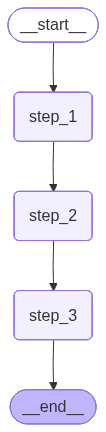

In [9]:
graph

In [10]:
try:
    print("Running graph")
    graph.invoke({'input':'start'},config={'configurable':{'thread_id':'thread-1'}})

except KeyboardInterrupt:
    print("Kernel manually interupted")

Running graph
Step-1 executed
Step-2 hanging now interrupt using keyboard
Kernel manually interupted


resuming workflow

In [11]:
final_state=graph.invoke(None,config={'configurable':{'thread_id':'thread-1'}})
print("FInal State: ",final_state)

Step-2 hanging now interrupt using keyboard
Step-3 executed
FInal State:  {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}
